In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [13]:
print("hello")

hello


In [14]:
df=pd.read_csv("HousingData.csv")
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  


In [15]:
print(df.isnull().values.any())
df.isnull().sum()
#RM and MEDV values are not null so right now for simplicity we will only consider RM and MEDV.

True


CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

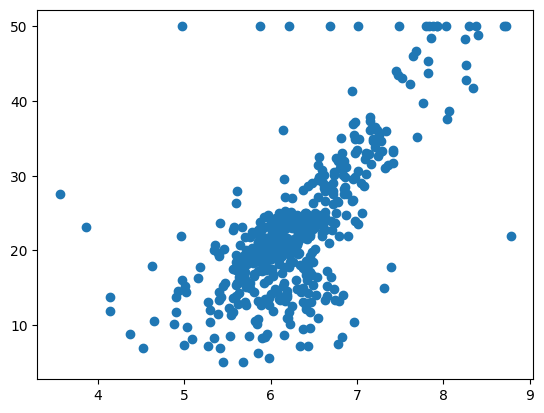

In [16]:
plt.scatter(df["RM"],df["MEDV"])
plt.show()

In [17]:
"""
RM= Total number of rooms in the dwelling
MEDV= Median value of house in dollars($).
Now we will plot a regression line for predicting MEDV for given RM's.
"""
x=df["RM"].to_numpy()
y=df["MEDV"].to_numpy()
print("X shape: ",x.shape)
print("Y shape: ",y.shape)

X shape:  (506,)
Y shape:  (506,)


In [18]:
def compute_cost(x,y,w,b):
    m=x.shape[0]
    cost_sum=0
    for i in range(m):
        line_pt=w*x[i]+b
        cost=(line_pt-y[i])**2
        cost_sum+=cost
    total_sum=(1/(2*m))*cost_sum
    return total_sum

In [19]:
def compute_gradient_descent(x,y,w,b):
    m=x.shape[0]
    init_weight=0
    init_bias=0
    for i in range(m):
        line_pt=w*x[i]+b
        init_weight_val=(line_pt-y[i])*x[i]
        init_bias_val=(line_pt-y[i])
        init_weight+=init_weight_val
        init_bias+=init_bias_val
    init_weight=init_weight/m
    init_bias=init_bias/m
    return init_weight,init_bias
    

In [39]:

def gradient_descent(x,y,w,b,alpha,epochs,cost_history):
    for i in range(epochs):
        wg,bg=compute_gradient_descent(x,y,w,b)
        w=w-(alpha*wg)
        b=b-(alpha*bg)
        cost_history.append(compute_cost(x,y,w,b))
    return w,b,cost_history


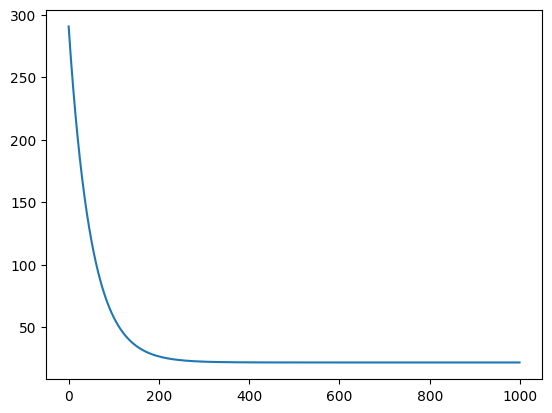

In [60]:
weight=0
bias=0
alpha=0.01
epochs=1000
cost_history=[]
mean=x.mean()
std=x.std()
x=(x-mean)/std
fw,fb,cost_history=gradient_descent(x,y,weight,bias,alpha=alpha,epochs=epochs,cost_history=cost_history)
plt.plot(cost_history)

6.388699401787342 22.53183355475399


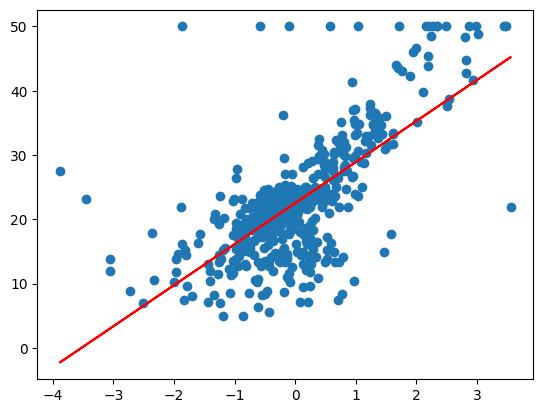

In [61]:
print(fw,fb)
plt.scatter(x,y)
plt.plot(x,fw*x+fb,color="red")